# 1 – BreastGNN: Results & Bootstrap Analysis

Post-hoc analysis pipeline: carga un bundle entrenado y ejecuta:
- Evaluación con umbrales OVR y bias por clase
- Bootstrap 95% CI (hard labels + AUC OVR)
- Explicabilidad Grad×Input
- Enrichment (gProfiler / Enrichr / KEGG overlay)
- Análisis de ejes biológicos


## 0) Imports

In [1]:
import os, sys
sys.path.insert(0, "..")  # ajustar si breastgnn está en otra ruta

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ── Core pipeline ──
from breastgnn.config import CFG
from breastgnn.utils import set_seed, set_all_seeds, cleanup_memory, get_device
from breastgnn.data import (
    load_expression_and_metadata, prepare_genes, encode_labels,
    cohort_split, scale_features, apply_connected_only,
    make_dataloaders, build_regulator_features,
)
from breastgnn.graph import build_backbone
from breastgnn.graph_cache import get_or_build_backbone, get_or_build_Xh
from breastgnn.losses import compute_metrics_full, compute_class_weights_balanced
from breastgnn.training import predict_proba_xh_mode
from breastgnn.pruning import export_pruned_graph, evaluate_keep_ratios
from breastgnn.stability import edge_set_from_edge_index, pairwise_jaccard_stats

# ── Ablation / bundle ──
from breastgnn.ablation import (
    AblationConfig, load_bundle, build_pruned_model_from_bundle,
    register_runtime, get_full_gene_matrix_and_genes,
)

# ── Post-processing ──
from breastgnn.postprocessing import (
    ovr_thresholds_from_val, predict_with_ovr_thresholds,
    plot_confusion_matrix,
    gene_importance_grad_x_input, aggregate_gene_importance,
)

# ── Bootstrap ──
from breastgnn.bootstrap import (
    scores_from_proba, tune_class_biases,
    bootstrap_classification_ci, bootstrap_auc_ovr_ci,
)

# ── Visualization ──
from breastgnn.visualization import (
    plot_pruned_subgraph_all_components, plot_components_grid,
    draw_global_graph_from_bundle,
)

# ── Axes ──
from breastgnn.axes import (
    compute_axis_scores, plot_axis_boxplots,
    plot_axis_heatmap_by_subtype, plot_axis_correlation,
    plot_axis_embedding, axis_stats_by_subtype,
    one_vs_rest_axis_analysis, summarize_one_vs_rest,
    plot_one_vs_rest_heatmap,
)

set_seed(CFG.SEED)
DEVICE = CFG.DEVICE
print("DEVICE:", DEVICE)


DEVICE: cuda


## 1) Configuración

Overrides opcionales. Ajusta rutas si es necesario.

In [2]:
# CFG.DATA_DIR = Path("../Listados_tumores/output_combat/").resolve()
# CFG.ARTIFACTS_ROOT = "./artifacts_ablation"
print("Config OK")


Config OK


## 2) Data pipeline (datos + grafo + split + escalado)

In [3]:
# ── Cargar expresión y metadata ──
X_df, y_str, cohort = load_expression_and_metadata(
    CFG.EXPR_CSV, CFG.META_CSV,
    sample_col=CFG.SAMPLE_COL, label_col=CFG.LABEL_COL, cohort_col=CFG.COHORT_COL,
)
X_df_kegg, genes_kegg = prepare_genes(X_df)
y, classes, label_map = encode_labels(y_str)
n_classes = len(classes)


X_df: (5812, 11907) | y: (5812,) | cohort: (5812,)
Targets:
 LumA      2514
LumB      1202
TNBC      1026
HER2       602
Normal     468
Name: count, dtype: int64
Genes totales (nodos): 11907
y: (5812,), n_classes: 5, classes: ['HER2', 'LumA', 'LumB', 'Normal', 'TNBC']


In [4]:
# ── Backbone graph (con caché) ──
edge_index, edge_weight, edge_type = get_or_build_backbone(
    genes_kegg,
    cache_dir=CFG.PIPELINE_CACHE_DIR,
    force_rebuild=False,
    use_omnipath=CFG.USE_OMNIPATH,
    use_huri=CFG.USE_HURI,
)
print(f"Backbone: {edge_index.shape[1]} aristas, {len(genes_kegg)} genes")


[graph_cache] Intentando cargar backbone: backbone__362de41006ca05c1__e71ae7463734.npz
[graph_cache] Backbone válido desde caché: 51445 aristas, 11907 genes
Backbone: 51445 aristas, 11907 genes


In [5]:
# ── Split + escalado + connected-only ──
train_idx, val_idx, test_idx = cohort_split(
    cohort, y, train_cohort_frac=0.80, val_size=CFG.VAL_SIZE, seed=CFG.SEED,
)
Xs_gene = scale_features(X_df_kegg, train_idx, mode=CFG.SCALE_MODE, use_quantile=CFG.USE_QUANTILE)

if CFG.CONNECTED_ONLY:
    Xs_gene, edge_index, edge_weight, edge_type, genes_kegg = apply_connected_only(
        Xs_gene, edge_index, edge_weight, edge_type, genes_kegg,
    )


Total cohorts: 12
Split sizes: train=3805, val=952, test=1055
Cohorts TRAIN: ['GSE1456', 'GSE15852', 'GSE162228', 'GSE19615', 'GSE20711', 'GSE21653', 'GSE25066', 'GSE65194', 'GSE96058']
Cohorts TEST: ['GSE32646', 'GSE58812', 'TCGA']
[CONNECTED_ONLY] 11907 -> 7213 genes, 51445 -> 51445 edges


In [6]:
# ── Regulator features (con caché) ──
Xs_graph, graph_feat_names = get_or_build_Xh(
    Xs_gene, genes_kegg, edge_index,
    cache_dir=CFG.PIPELINE_CACHE_DIR,
    stats=CFG.REG_STATS,
    min_targets=CFG.REG_MIN_GENES,
    max_regulators=CFG.REG_MAX_REGULATORS,
)
print(f"Xs_graph: {Xs_graph.shape}")


[graph_cache] Cargando Xs_graph (X_h) desde caché: Xh__0575558be8d8a450__c102b7893b38__2060915c8ab9.npz
[graph_cache]   → Xs_graph shape: (5812, 7611)
Xs_graph: (5812, 7611)


In [7]:
# ── DataLoaders ──
dl_tr, dl_va, dl_te = make_dataloaders(
    Xs_gene, Xs_graph, y, train_idx, val_idx, test_idx,
    batch_size=CFG.BATCH_SIZE,
)


Batches train/val/test: 191/48/53


In [8]:
# ── Tensores de grafo + registro en runtime ──
edge_index_t = torch.as_tensor(edge_index, dtype=torch.long, device=DEVICE)
edge_weight_t = torch.as_tensor(edge_weight, dtype=torch.float32, device=DEVICE)
edge_type_t = torch.as_tensor(edge_type, dtype=torch.long, device=DEVICE)

register_runtime(
    Xs_gene=Xs_gene, genes_kegg=genes_kegg,
    X_h=Xs_graph, y=y, n_classes=n_classes, label_map=label_map,
    train_idx=train_idx, val_idx=val_idx, test_idx=test_idx,
    edge_index_t=edge_index_t, edge_weight_t=edge_weight_t,
    edge_type_t=edge_type_t,
)


## 3) Cargar bundle y modelo pre-entrenado

In [9]:
BUNDLE_DIR = os.path.join(CFG.ARTIFACTS_ROOT, "FULL", "seed_1234")
bundle = load_bundle(BUNDLE_DIR)

meta_b = bundle.get("meta", {})
splits = meta_b.get("splits", {})
g = bundle["graph"]
print("Bundle cargado:", list(bundle.keys()))


Bundle cargado: ['meta', 'graph', 'model']


In [10]:
# ── Reconstruir espacio compacto del modelo ──
nodes_used = np.asarray(g["nodes_used_full"], dtype=np.int64)
X_full, genes_full = get_full_gene_matrix_and_genes()
genes_model = [str(genes_full[i]) for i in nodes_used]
Xs_gene_compact = X_full[:, nodes_used]

print(f"Modelo compacto: {len(genes_model)} genes, Xs_gene_compact: {Xs_gene_compact.shape}")


Modelo compacto: 291 genes, Xs_gene_compact: (5812, 291)


In [11]:
# ── Cargar modelo con pesos ──
model_loaded = build_pruned_model_from_bundle(bundle, device=DEVICE)
model_loaded.eval()
print("Modelo cargado:", type(model_loaded).__name__)


Modelo cargado: HybridGNNTabular


In [12]:
# ── Dataloaders compactos ──
dl_va_c, dl_te_c = [
    torch.utils.data.DataLoader(
        __import__("breastgnn.data", fromlist=["ExpressionDataset"]).ExpressionDataset(
            Xs_gene_compact, Xs_graph, y, idx
        ),
        batch_size=CFG.BATCH_SIZE, shuffle=False,
    )
    for idx in [val_idx, test_idx]
]

# ── Predicciones ──
proba_va, y_va = predict_proba_xh_mode(model_loaded, None, dl_va_c, DEVICE, xh_mode="orig")
proba_te, y_te = predict_proba_xh_mode(model_loaded, None, dl_te_c, DEVICE, xh_mode="orig")
print(f"proba_va: {proba_va.shape}, proba_te: {proba_te.shape}")


proba_va: (952, 5), proba_te: (1055, 5)


## 4) Grafo podado: nodos, grados, export

In [13]:
# ── Extraer edge_index del bundle ──
edge_index_p = g.get("edge_index_compact", g.get("edge_index_comp"))
edge_weight_p = g.get("edge_weight_compact", g.get("edge_weight_comp"))
if torch.is_tensor(edge_index_p):
    edge_index_p = edge_index_p.cpu()
    edge_weight_p = edge_weight_p.cpu() if torch.is_tensor(edge_weight_p) else edge_weight_p

n_total = len(genes_model)
node_ids = torch.unique(edge_index_p.reshape(-1)).cpu().numpy()
node_ids = np.sort(node_ids)
genes_used = [genes_model[i] for i in node_ids]

print(f"[NODES total model]: {n_total}")
print(f"[NODES used in pruned graph]: {len(node_ids)}")

# Grados
deg = np.zeros(n_total, dtype=int)
src, dst = edge_index_p[0].cpu().numpy(), edge_index_p[1].cpu().numpy()
for u in src: deg[u] += 1
for v in dst: deg[v] += 1

df_deg = pd.DataFrame({"node_id": np.arange(n_total), "gene": genes_model, "degree_in_pruned": deg})
df_deg_used = df_deg[df_deg["degree_in_pruned"] > 0].sort_values("degree_in_pruned", ascending=False)
print("Top genes by degree:")
display(df_deg_used.head(20))


[NODES total model]: 291
[NODES used in pruned graph]: 291
Top genes by degree:


,node_id,gene,degree_in_pruned
79,79,ESR1,8
70,70,EGFR,7
261,261,TP53,7
273,273,UBQLN2,7
109,109,HOXA1,6
141,141,MAGEA6,5
1,1,ABL1,5
104,104,GSC2,4
100,100,GORASP2,4
33,33,CDK1,4


In [14]:
# ── Gene symbols del subgrafo + máscara ──
gene_symbols_pruned = (
    df_deg_used["gene"].astype(str).str.strip()
    .replace("", np.nan).dropna().drop_duplicates().tolist()
)
G_total = Xs_gene_compact.shape[1]
pruned_ids = df_deg_used["node_id"].astype(int).to_numpy()
gene_mask_pruned = np.zeros(G_total, dtype=bool)
gene_mask_pruned[pruned_ids] = True

print(f"Gene symbols únicos: {len(gene_symbols_pruned)}")
print(f"Genes en máscara pruned: {gene_mask_pruned.sum()}")

# Para enrichment / KEGG
genes_ckpt = list(gene_symbols_pruned)


Gene symbols únicos: 291
Genes en máscara pruned: 291


## 5) Visualización del grafo

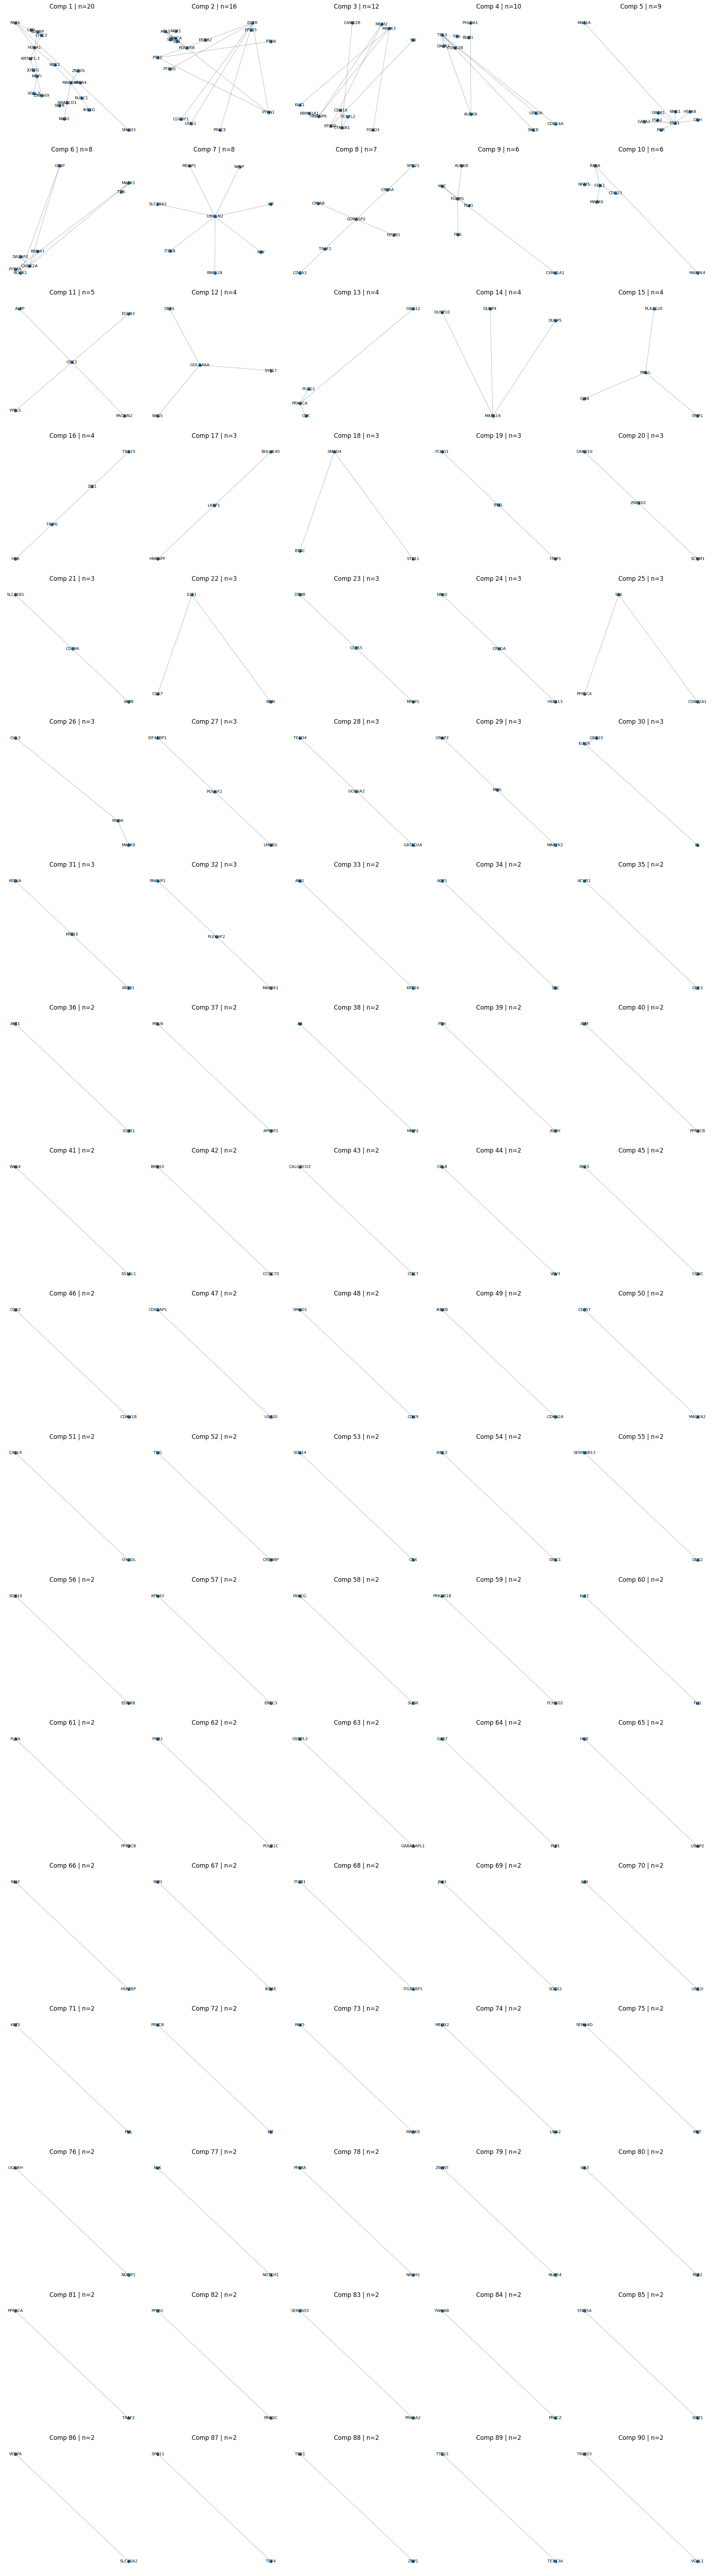

In [15]:
# ── Componentes del subgrafo ──
G_all, pos_all, comps_all = plot_pruned_subgraph_all_components(edge_index_p, edge_weight_p)
plot_components_grid(G_all, genes=genes_model)


[SAVE] ./figures_axes_refined/Grafo_final.png


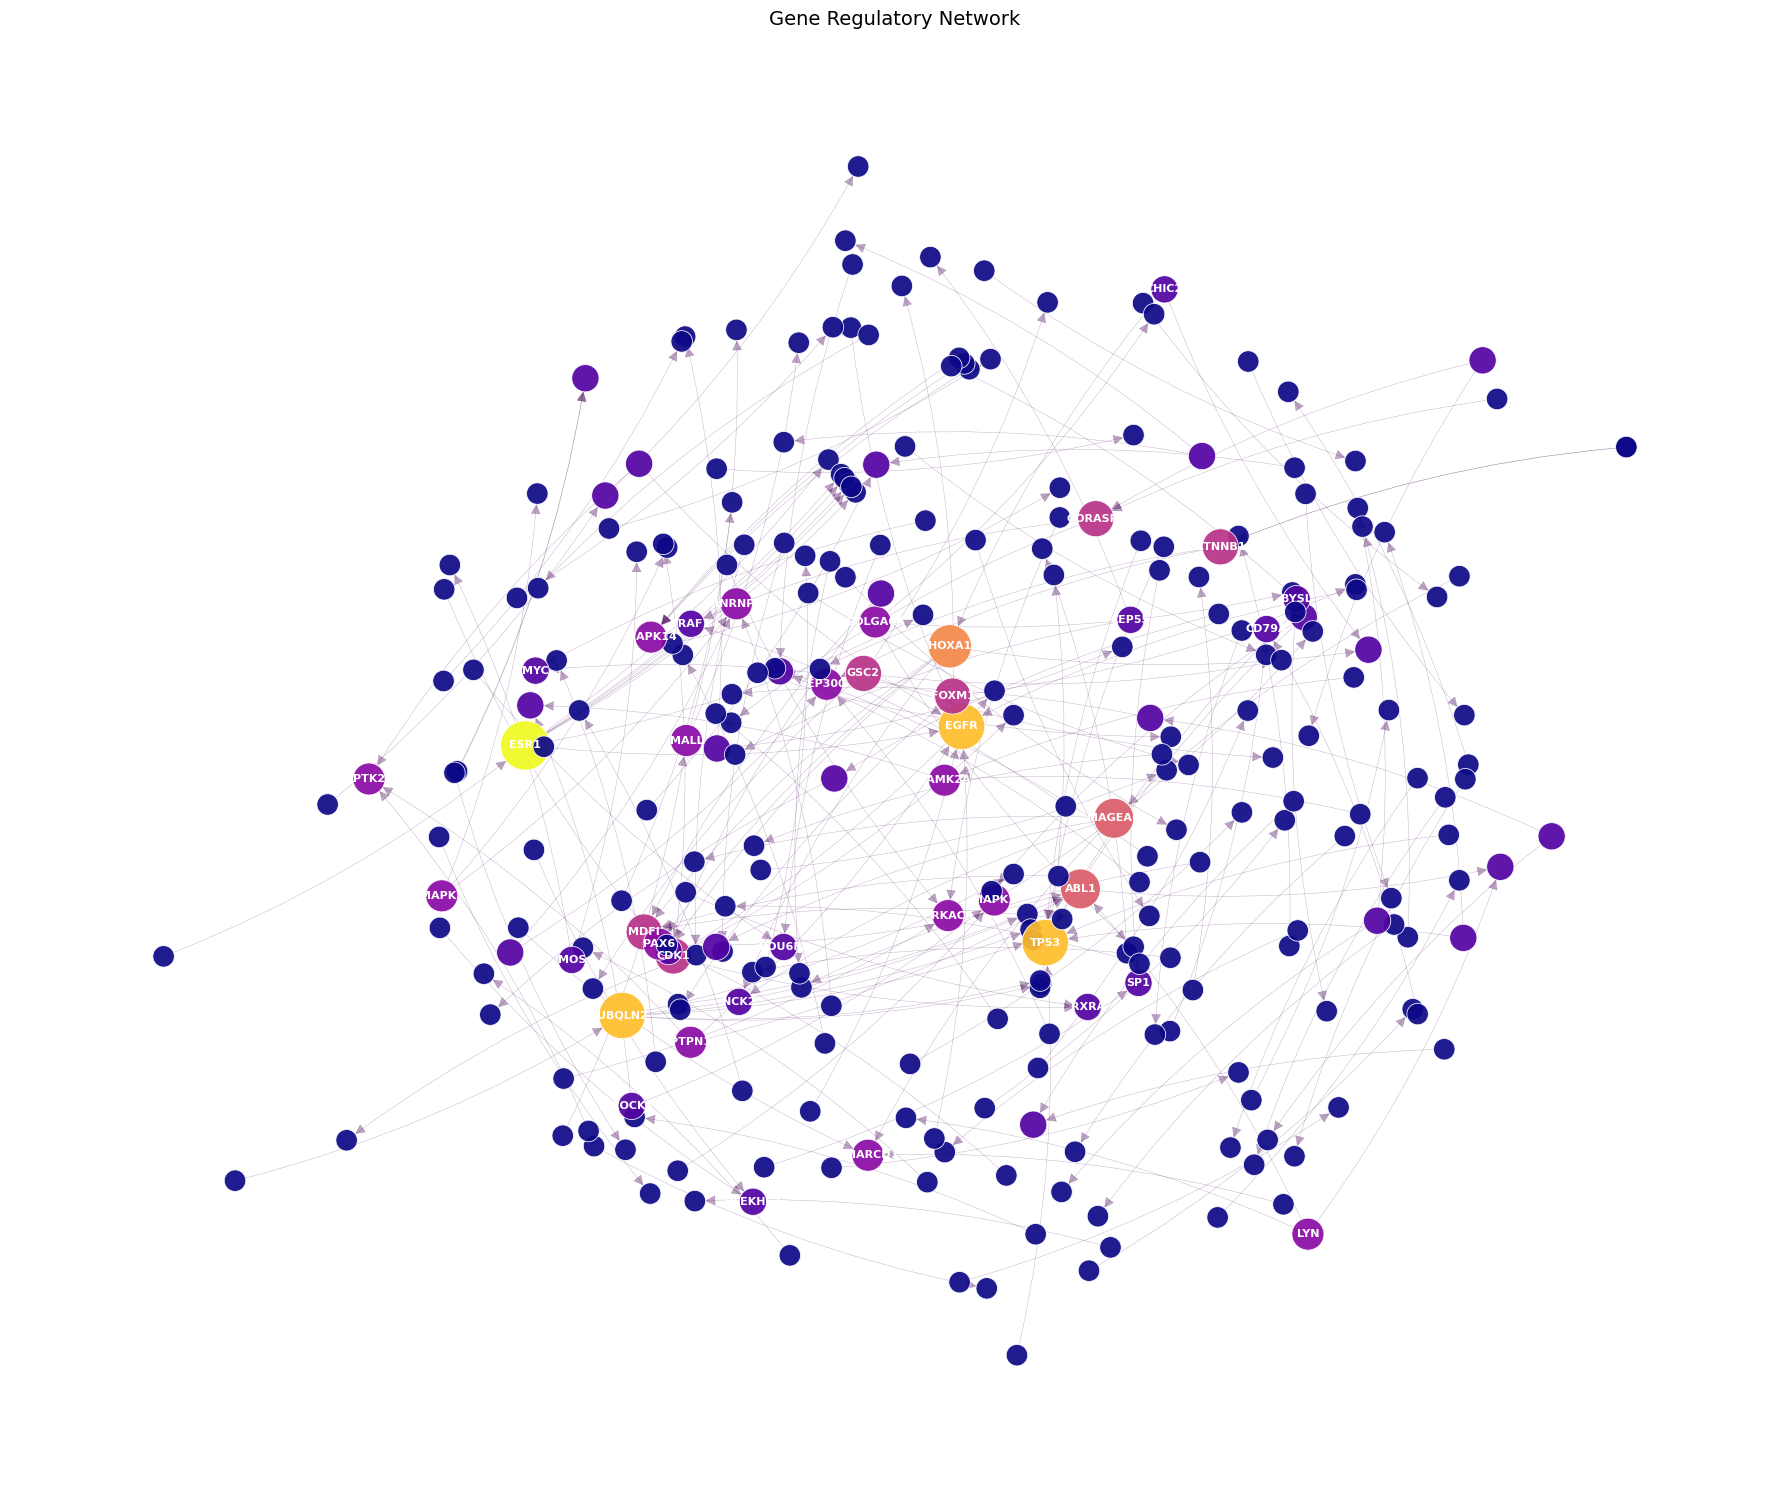

(<Figure size 1800x1500 with 1 Axes>,
 <Axes: title={'center': 'Gene Regulatory Network'}>)

In [16]:
# ── Grafo dirigido completo desde bundle ──
draw_global_graph_from_bundle(
    bundle,
    title="Gene Regulatory Network",
    layout="kamada_kawai", seed=42,
    figsize=(18, 15), facecolor="#0d1117",
    node_color_mode="degree", node_cmap=plt.cm.plasma,
    node_size_mode="degree", node_size_base=60.0, node_size_scale=1200.0,
    node_alpha=0.92, node_edgecolor="#ffffff", node_linewidth=0.6,
    top_labels=40, label_fontsize=8, label_fontweight="bold", label_bbox_alpha=0.0,
    edge_color_mode="weight", edge_cmap=plt.cm.cool,
    edge_width_mode="weight", edge_width_min=0.3, edge_width_max=2.8, edge_alpha=0.35,
    arrows=True, arrowstyle="-|>", arrowsize=16,
    connectionstyle="arc3,rad=0.08",
    show_colorbar_nodes=False, show_colorbar_edges=False,
    annotate_stats=False,
    save_path="./figures_axes_refined/Grafo_final.png", dpi=300,
)


## 6) Classification report + umbrales OVR

              precision    recall  f1-score   support

        HER2      0.833     0.844     0.839        77
        LumA      0.952     0.990     0.971       421
        LumB      0.974     0.984     0.979       193
      Normal      0.873     0.842     0.857       114
        TNBC      0.957     0.896     0.926       250

    accuracy                          0.940      1055
   macro avg      0.918     0.911     0.914      1055
weighted avg      0.940     0.940     0.940      1055



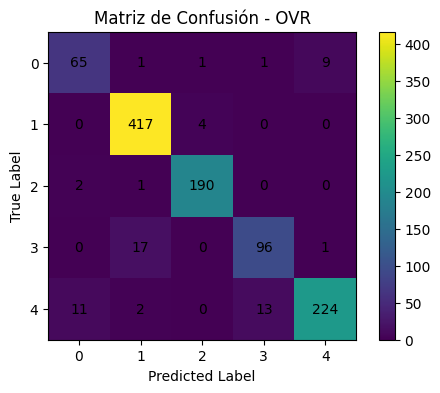

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

num_classes = proba_te.shape[1]

# ── OVR thresholds optimizados en validación ──
thr_ovr = ovr_thresholds_from_val(proba_va, y_va, num_classes, grid=np.linspace(0.01, 0.99, 300))
y_pred_ovr = predict_with_ovr_thresholds(proba_te, thr_ovr)

print(classification_report(y_te, y_pred_ovr, target_names=classes, digits=3))
_ = plot_confusion_matrix(y_te, y_pred_ovr, classes, title="Matriz de Confusión - OVR")


## 7) Calibración por class bias (greedy)

[BIAS] Clase de referencia fija: LumA
[BIAS] Macro-F1 inicial (sin/antes de calibrar): 0.9152
[BIAS] pass=1 clase=HER2 -> bias=+0.050 | macroF1=0.9168
[BIAS] Sin mejoras en pass 2; paro.

=== Test con class biases ===
              precision    recall  f1-score   support

        HER2      0.838     0.870     0.854        77
        LumA      0.950     0.990     0.970       421
        LumB      0.974     0.984     0.979       193
      Normal      0.888     0.833     0.860       114
        TNBC      0.962     0.900     0.930       250

    accuracy                          0.942      1055
   macro avg      0.922     0.916     0.918      1055
weighted avg      0.942     0.942     0.942      1055



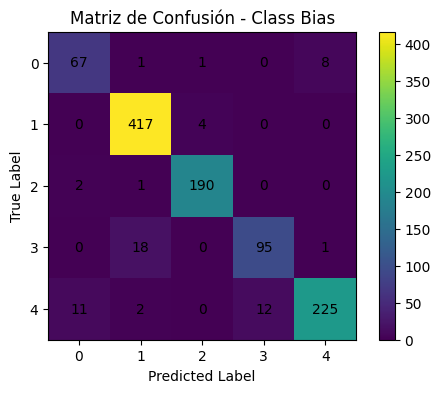

In [18]:
scores_val = scores_from_proba(proba_va)
scores_te = scores_from_proba(proba_te)

best_bias, best_f1_bias = tune_class_biases(
    scores_val, y_va, classes=classes,
    n_passes=3, verbose=True,
)

from breastgnn.bootstrap import predict_with_class_bias
y_pred_bias = predict_with_class_bias(scores_te, best_bias)

print("\n=== Test con class biases ===")
print(classification_report(y_te, y_pred_bias, target_names=classes, digits=3))
_ = plot_confusion_matrix(y_te, y_pred_bias, classes, title="Matriz de Confusión - Class Bias")


## 8) Bootstrap 95% CI

### 8a) Bootstrap métricas hard-label

In [19]:
# Usa la predicción final que prefieras (OVR o class-bias)
y_pred_final = y_pred_ovr

boot_ci = bootstrap_classification_ci(
    y_true=y_te, y_pred=y_pred_final,
    class_names=classes, B=10_000, seed=42,
)

print("=== Bootstrap CI (overall) ===")
display(boot_ci["overall"])
print("=== Bootstrap CI (per-class) ===")
display(boot_ci["per_class"])
print("=== Observed confusion matrix ===")
display(boot_ci["observed_confusion_matrix"])

# Guardar
os.makedirs("./Results", exist_ok=True)
boot_ci["overall"].to_csv("./Results/bootstrap_ci_overall_test.csv", index=False)
boot_ci["per_class"].to_csv("./Results/bootstrap_ci_per_class_test.csv", index=False)


=== Bootstrap CI (overall) ===


,metric,point_estimate,ci_low,ci_high,ci_95_percentile
0,accuracy,0.940284,0.925118,0.954502,"[0.9251, 0.9545]"
1,macro_precision,0.917948,0.894670,0.939539,"[0.8947, 0.9395]"
2,macro_recall,0.911443,0.887944,0.933866,"[0.8879, 0.9339]"
3,macro_f1,0.914350,0.891944,0.934316,"[0.8919, 0.9343]"
4,weighted_f1,0.939780,0.924621,0.954183,"[0.9246, 0.9542]"


=== Bootstrap CI (per-class) ===


,class,metric,point_estimate,ci_low,ci_high,ci_95_percentile,support
0,HER2,precision,0.833333,0.746667,0.911402,"[0.7467, 0.9114]",77
1,HER2,recall,0.844156,0.758065,0.921053,"[0.7581, 0.9211]",77
2,HER2,f1,0.838710,0.770270,0.897727,"[0.7703, 0.8977]",77
3,LumA,precision,0.952055,0.931414,0.971367,"[0.9314, 0.9714]",421
4,LumA,recall,0.990499,0.980263,0.997722,"[0.9803, 0.9977]",421
5,LumA,f1,0.970896,0.958837,0.981640,"[0.9588, 0.9816]",421
6,LumB,precision,0.974359,0.949772,0.994624,"[0.9498, 0.9946]",193
7,LumB,recall,0.984456,0.964103,1.000000,"[0.9641, 1.0000]",193
8,LumB,f1,0.979381,0.963351,0.992366,"[0.9634, 0.9924]",193
9,Normal,precision,0.872727,0.808081,0.931373,"[0.8081, 0.9314]",114


=== Observed confusion matrix ===


,HER2,LumA,LumB,Normal,TNBC
HER2,65,1,1,1,9
LumA,0,417,4,0,0
LumB,2,1,190,0,0
Normal,0,17,0,96,1
TNBC,11,2,0,13,224


### 8b) Bootstrap AUC OVR

In [20]:
boot_auc = bootstrap_auc_ovr_ci(
    y_true=y_te, proba=proba_te,
    class_names=classes, B=10_000, seed=42,
)

print("=== AUC Bootstrap CI (overall) ===")
display(boot_auc["macro"])
print("=== AUC Bootstrap CI (per-class) ===")
display(boot_auc["per_class"])

boot_auc["macro"].to_csv("./Results/bootstrap_auc_overall.csv", index=False)
boot_auc["per_class"].to_csv("./Results/bootstrap_auc_per_class.csv", index=False)


=== AUC Bootstrap CI (overall) ===


,metric,point_estimate,ci_low,ci_high,ci_95_percentile,n_boot_valid,n_boot_total
0,auc_ovr_macro,0.990573,0.985162,0.994982,"[0.9852, 0.9950]",10000,10000


=== AUC Bootstrap CI (per-class) ===


,class,metric,point_estimate,ci_low,ci_high,ci_95_percentile,n_boot_valid,n_boot_total,n_positive_obs,n_negative_obs
0,HER2,auc_ovr,0.975646,0.953190,0.992950,"[0.9532, 0.9929]",10000,10000,77,978
1,LumA,auc_ovr,0.998524,0.997340,0.999414,"[0.9973, 0.9994]",10000,10000,421,634
2,LumB,auc_ovr,0.999050,0.997544,0.999897,"[0.9975, 0.9999]",10000,10000,193,862
3,Normal,auc_ovr,0.988665,0.981389,0.994429,"[0.9814, 0.9944]",10000,10000,114,941
4,TNBC,auc_ovr,0.990981,0.985539,0.995399,"[0.9855, 0.9954]",10000,10000,250,805


## 9) Explicabilidad: Grad×Input

In [21]:
assert Xs_gene_compact.shape[1] == len(genes_model), "Xs_gene_compact no coincide con genes_model"

Xg_test = Xs_gene_compact[test_idx]
Xh_test = Xs_graph[test_idx]
y_test = y[test_idx]

imp_by_class = {}
for c in range(n_classes):
    imp_by_class[c] = aggregate_gene_importance(
        model_loaded, Xg_test, Xh_test, y_test,
        class_id=c, device=DEVICE, max_samples=200,
        gene_mask=gene_mask_pruned, zero_outside=True,
    )


grad×input class=4: 100%|██████████████████████████████████████████████████████████████████| 200/200 [00:01<00:00, 147.03it/s]


In [22]:
TOPK = 500
use_idx = np.where(gene_mask_pruned)[0]

top_genes_by_class = {}
for c in range(n_classes):
    scores = imp_by_class[c][use_idx]
    order_local = np.argsort(-scores)[:min(TOPK, scores.size)]
    top_global = use_idx[order_local]
    top_genes_by_class[c] = [(genes_model[i], float(imp_by_class[c][i])) for i in top_global]

# Top-10 por clase
for c in range(n_classes):
    print(f"\n--- {classes[c]} ---")
    print(top_genes_by_class[c][:10])



--- HER2 ---
[('APOA4', 0.1078401654958725), ('ESR1', 0.09438817203044891), ('PLA2G2E', 0.07452765852212906), ('NPVF', 0.053630903363227844), ('MAT1A', 0.053596943616867065), ('FOXM1', 0.04209533706307411), ('GOLGA6A', 0.036533601582050323), ('CDK1', 0.036473602056503296), ('ERBB2', 0.03534363955259323), ('CHIC2', 0.034774549305438995)]

--- LumA ---
[('UBQLN2', 0.18206828832626343), ('APOA4', 0.13866780698299408), ('CHIC2', 0.05453302711248398), ('MAGEA6', 0.03991479426622391), ('ESR1', 0.03865977004170418), ('CDH16', 0.03846486657857895), ('MALL', 0.035376302897930145), ('CRYAA', 0.029255304485559464), ('MAT1A', 0.026612011715769768), ('ZIC1', 0.02644653059542179)]

--- LumB ---
[('NPVF', 0.39557522535324097), ('APOA4', 0.30450552701950073), ('CHIC2', 0.07178235799074173), ('CDH16', 0.06573700159788132), ('MAT1A', 0.05946704000234604), ('CRYAA', 0.055498380213975906), ('ZIC1', 0.04889978468418121), ('CAMK2B', 0.04385611042380333), ('PLA2G2E', 0.04068702086806297), ('MALL', 0.0399417

In [23]:
# Guardar importancias de la clase TARGET
TARGET_CLASS_ID = label_map.get("TNBC", 0)
pd.DataFrame(top_genes_by_class[TARGET_CLASS_ID], columns=["gene", "importance"]).to_csv(
    "./Results/genes_grafo_TARGET_Importancia.csv", index=False
)
df_deg_used.to_csv("./Results/genes_grafo.csv")


## 10) Enrichment (gProfiler / Enrichr / KEGG)

Requiere internet y paquetes opcionales: `gprofiler-official`, `gseapy`, `mygene`.

In [ ]:
import re

gene_list = [str(g).strip().upper() for g in gene_symbols_pruned]
keep_tag = "pruned"
OUT_PREFIX = f"enrich_keep_{keep_tag}"
print(f"Genes para enrichment: {len(gene_list)}")

# ── gProfiler (GO + Reactome + KEGG) ──
try:
    from gprofiler import GProfiler
    gp = GProfiler(return_dataframe=True)
    res = gp.profile(organism="hsapiens", query=gene_list,
                     sources=["GO:BP", "GO:MF", "GO:CC", "REAC", "KEGG"])
    display(res.head(20))
    res.to_csv(f"./Results/{OUT_PREFIX}_gprofiler_GO_REAC_KEGG.csv", index=False)
except Exception as e:
    print("[WARN] gprofiler:", e)

# ── Enrichr via gseapy (fallback) ──
try:
    import gseapy as gpy
    libs = gpy.get_library_name()
    kegg_libs = [l for l in libs if re.match(r"^KEGG_\d{4}_Human$", l)]
    kegg_lib = sorted(kegg_libs, key=lambda x: int(x.split("_")[1]))[-1] if kegg_libs else "KEGG_2021_Human"

    for gs, tag in [(kegg_lib, "KEGG"), ("Reactome_2022", "REACTOME"),
                    ("GO_Biological_Process_2023", "GO_BP"),
                    ("GO_Molecular_Function_2023", "GO_MF"),
                    ("GO_Cellular_Component_2023", "GO_CC")]:
        enr = gpy.enrichr(gene_list=gene_list, gene_sets=[gs], organism="human", outdir=None, cutoff=0.5)
        df = enr.results.copy() if hasattr(enr, "results") else pd.DataFrame()
        if not df.empty:
            df.to_csv(f"./Results/{OUT_PREFIX}_{tag}.csv", index=False)
            display(df.head(10))
except Exception as e:
    print("[WARN] gseapy:", e)


Genes para enrichment: 291


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,GO:BP,GO:0035556,intracellular signal transduction,2.729099e-45,True,"""The process in which a signal is passed on to...",2965,283,143,21026,0.505300,0.048229,query_1,[GO:0007165]
1,GO:BP,GO:0048518,positive regulation of biological process,4.430585e-42,True,"""Any process that activates or increases the f...",6264,283,199,21026,0.703180,0.031769,query_1,"[GO:0008150, GO:0050789]"
2,GO:BP,GO:0009893,positive regulation of metabolic process,8.102025e-42,True,"""Any process that activates or increases the f...",3597,283,152,21026,0.537102,0.042257,query_1,"[GO:0008152, GO:0019222, GO:0048522]"
3,GO:BP,GO:0048522,positive regulation of cellular process,7.888051e-41,True,"""Any process that activates or increases the f...",5920,283,192,21026,0.678445,0.032432,query_1,"[GO:0009987, GO:0048518, GO:0050794]"
4,GO:BP,GO:0010604,positive regulation of macromolecule metabolic...,4.707067e-39,True,"""Any process that increases the frequency, rat...",3288,283,142,21026,0.501767,0.043187,query_1,"[GO:0009893, GO:0043170, GO:0060255]"
5,GO:BP,GO:0141124,intracellular signaling cassette,1.710772e-37,True,"""An intracellular signaling module that is par...",1912,283,108,21026,0.381625,0.056485,query_1,[GO:0035556]
6,GO:BP,GO:0009966,regulation of signal transduction,4.192795e-37,True,"""Any process that modulates the frequency, rat...",3034,283,134,21026,0.473498,0.044166,query_1,"[GO:0007165, GO:0010646, GO:0023051, GO:0048583]"
7,GO:BP,GO:0023051,regulation of signaling,3.598725e-36,True,"""Any process that modulates the frequency, rat...",3478,283,142,21026,0.501767,0.040828,query_1,"[GO:0023052, GO:0050789]"
8,GO:BP,GO:0010646,regulation of cell communication,4.710183e-36,True,"""Any process that modulates the frequency, rat...",3486,283,142,21026,0.501767,0.040734,query_1,"[GO:0007154, GO:0050794]"
9,GO:BP,GO:1902531,regulation of intracellular signal transduction,7.839887e-36,True,"""Any process that modulates the frequency, rat...",1953,283,107,21026,0.378092,0.054788,query_1,"[GO:0009966, GO:0035556]"


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Pathways in cancer,59/531,5.019441e-35,1.179569e-32,0,0,10.364763,818.579536,ITGB1;CDKN1B;PTEN;IGF1R;IKBKB;EDNRB;MYC;AKT1;E...
1,KEGG_2021_Human,ErbB signaling pathway,26/85,1.297900e-27,1.525033e-25,0,0,32.676687,2022.982641,CAMK2B;CDKN1B;SRC;CAMK2A;CBLB;EGFR;MAPK9;MAPK8...
2,KEGG_2021_Human,FoxO signaling pathway,28/131,7.238502e-25,5.670160e-23,0,0,20.265348,1126.453660,CDKN1B;PRKAA2;PTEN;FOXO3;NLK;EGFR;IGF1R;IKBKB;...
3,KEGG_2021_Human,Kaposi sarcoma-associated herpesvirus infection,32/193,1.261716e-24,7.412583e-23,0,0,15.001223,825.510843,SRC;IKBKB;MAPK9;PPP3CB;MAPK8;TBK1;MYC;E2F1;AKT...
4,KEGG_2021_Human,Hepatitis B,29/162,2.170546e-23,1.020157e-21,0,0,16.291798,850.178988,YWHAB;SRC;IKBKB;MAPK9;MAPK8;TBK1;MYC;E2F1;AKT1...
5,KEGG_2021_Human,MAPK signaling pathway,36/294,6.402333e-23,2.507580e-21,0,0,10.643502,543.912700,PTPRR;NLK;EGFR;IGF1R;IKBKB;MAPK9;PPP3CB;MAPK8;...
6,KEGG_2021_Human,Proteoglycans in cancer,31/205,1.224484e-22,4.110768e-21,0,0,13.386052,675.384594,ITGB1;CAMK2B;ROCK1;SRC;CAMK2A;EGFR;IGF1R;MYC;E...
7,KEGG_2021_Human,Prostate cancer,22/97,2.234521e-20,6.563905e-19,0,0,21.410062,968.755525,PDGFRB;TCF7L2;MAP2K1;CREBBP;MAP2K2;CDKN1B;PTEN...
8,KEGG_2021_Human,Human T-cell leukemia virus 1 infection,29/219,1.355345e-19,3.538957e-18,0,0,11.371053,494.016071,PTEN;IKBKB;MAPK9;PPP3CB;MAPK8;CDC23;KAT5;MYC;E...
9,KEGG_2021_Human,Human cytomegalovirus infection,29/225,2.900766e-19,6.015535e-18,0,0,11.019571,470.360924,ROCK1;SRC;EGFR;IKBKB;PPP3CB;TBK1;MYC;EIF4EBP1;...


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,Reactome_2022,Signal Transduction R-HSA-162582,123/2465,4.374375e-38,4.877428e-35,0,0,5.429174,467.030938,NAB2;CCNC;CDC14A;IGF1R;STK11;EDNRB;KAT5;MYC;GR...
1,Reactome_2022,Signaling By Receptor Tyrosine Kinases R-HSA-9...,54/496,1.449747e-31,8.082337e-29,0,0,9.932012,705.259758,ITGB1;PTPRS;YWHAB;NAB2;LMNB2;IGF1R;MYC;GRAP2;G...
2,Reactome_2022,Disease R-HSA-1643685,90/1736,8.522427e-28,3.167502e-25,0,0,4.913676,306.267850,ITGB1;CDKN1B;YWHAB;PTEN;CCNC;GOLGA2;IKBKB;CDC2...
3,Reactome_2022,Generic Transcription Pathway R-HSA-212436,73/1190,1.339470e-26,3.733774e-24,0,0,5.573645,332.049556,CDKN1B;YWHAB;PTEN;CCNC;STK11;CDC23;KAT5;MYC;AK...
4,Reactome_2022,RNA Polymerase II Transcription R-HSA-73857,73/1312,5.074193e-24,1.131545e-21,0,0,4.991855,267.752490,CDKN1B;YWHAB;PTEN;CCNC;STK11;CDC23;KAT5;MYC;AK...
5,Reactome_2022,Gene Expression (Transcription) R-HSA-74160,75/1449,8.474396e-23,1.574825e-20,0,0,4.633420,235.481574,CDKN1B;YWHAB;PTEN;CCNC;STK11;CDC23;KAT5;MYC;AK...
6,Reactome_2022,Diseases Of Signal Transduction By Growth Fact...,39/424,3.137704e-20,4.997914e-18,0,0,7.767842,348.839870,CAMK2B;CDKN1B;NOTCH1;YWHAB;SRC;CAMK2A;PTEN;CCN...
7,Reactome_2022,Cytokine Signaling In Immune System R-HSA-1280215,48/702,2.605100e-19,3.630858e-17,0,0,5.755276,246.277739,ITGB1;CAMK2B;CDKN1B;CAMK2A;GATA3;FOXO3;IKBKB;P...
8,Reactome_2022,Infectious Disease R-HSA-5663205,54/961,7.431950e-18,9.207360e-16,0,0,4.723264,186.289024,ITGB1;YWHAB;IKBKB;TBK1;AKT1;IKBKG;BTRC;IKBKE;J...
9,Reactome_2022,ESR-mediated Signaling R-HSA-8939211,25/188,4.371486e-17,4.874207e-15,0,0,11.270123,424.532507,CDKN1B;SRC;GATA3;FOXO3;PRKCZ;EGFR;IGF1R;KAT5;M...


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2023,Protein Phosphorylation (GO:0006468),56/500,2.111330e-33,5.521129e-30,0,0,10.339659,777.935144,BMP10;IGF1R;IKBKB;PPP3CB;STK11;TBK1;AKT1;PRKAC...
1,GO_Biological_Process_2023,Protein Modification Process (GO:0036211),57/711,2.327308e-26,3.042955e-23,0,0,7.097252,418.897537,PTPRR;PTPRS;PTEN;GOLGA2;IKBKB;PPP3CB;STK11;TBK...
2,GO_Biological_Process_2023,Phosphorylation (GO:0016310),44/429,1.140031e-24,9.937269e-22,0,0,8.941122,492.932882,CAMK2B;PRKAA2;ROCK1;PRKDC;CAMK2A;PRKCZ;AURKB;A...
3,GO_Biological_Process_2023,Positive Regulation Of DNA-templated Transcrip...,69/1243,1.362391e-22,8.906629e-20,0,0,4.907051,247.058415,BMP10;CCNC;MEOX2;FOXM1;IKBKB;PPP3CB;TBK1;KAT5;...
4,GO_Biological_Process_2023,Regulation Of Transcription By RNA Polymerase ...,89/2028,2.381992e-22,1.245782e-19,0,0,4.037832,201.039360,CCNC;MEOX2;FOXM1;IKBKB;PPP3CB;EDNRB;TBK1;KAT5;...
5,GO_Biological_Process_2023,Peptidyl-Serine Phosphorylation (GO:0018105),26/158,4.134634e-20,1.802011e-17,0,0,14.551229,649.454874,CAMK2B;ROCK1;PRKDC;CAMK2A;TTK;PRKCZ;AURKA;IKBK...
6,GO_Biological_Process_2023,Positive Regulation Of Transcription By RNA Po...,56/938,1.012959e-19,3.784127e-17,0,0,5.086660,222.471382,CCNC;MEOX2;FOXM1;IKBKB;PPP3CB;TBK1;KAT5;MYC;NC...
7,GO_Biological_Process_2023,Regulation Of Cell Population Proliferation (G...,49/766,1.668422e-18,5.453654e-16,0,0,5.363302,219.544912,CXCL9;CDKN1B;PTEN;FOXM1;IGF1R;STK11;MYC;NCK2;A...
8,GO_Biological_Process_2023,Peptidyl-Serine Modification (GO:0018209),25/166,2.049405e-18,5.954659e-16,0,0,13.043246,531.238153,CAMK2B;ROCK1;PRKDC;CAMK2A;TTK;PRKCZ;AURKA;IKBK...
9,GO_Biological_Process_2023,Regulation Of DNA-templated Transcription (GO:...,78/1922,2.095666e-17,5.480167e-15,0,0,3.547783,136.249342,BMP10;CDKN1B;NAB2;MEOX2;FOXM1;IKBKB;PPP3CB;KAT...


### KEGG pathway overlay

In [ ]:
try:
    import mygene
    from breastgnn.enrichment import build_symbol_entrez_maps, plot_kegg_map_overlay

    symbol_to_entrez, entrez_to_symbol = build_symbol_entrez_maps(genes_ckpt)
    unmapped = [g for g in gene_list if g not in symbol_to_entrez]
    print(f"Unmapped symbols: {len(unmapped)}")
except ImportError:
    print("[WARN] mygene no disponible. Instala: pip install mygene")


In [ ]:
# Descomenta la ruta KEGG que quieras visualizar
try:
    for pathway in ["hsa05224", "hsa04110", "hsa05200"]:
        plot_kegg_map_overlay(
            pathway,
            selected_genes=gene_symbols_pruned,
            symbol_to_entrez=symbol_to_entrez,
            entrez_to_symbol=entrez_to_symbol,
            show_labels=True,
        )
except Exception as e:
    print("[WARN] KEGG overlay:", e)


## 11) Análisis de ejes biológicos

In [ ]:
AXES = {
    "Luminal Hormonal": [
        "ESR1","PGR","GATA3","GREB1","ESR2","PHLDA1","LRIG1","RXRA"
    ],
    "Cell Cycle Mitotic": [
        "AURKA","AURKB","BUB1","CDC7","CDC23","CDCA3","CDK1","CDK2",
        "CEP55","E2F1","FOXM1","PLK1","TTK","ZWINT"
    ],
    "HER2 RTK MAPK": [
        "ERBB2","EGFR","IGF1R","MET","PDGFRB","AKT1","MAP2K1","MAP2K2",
        "MAPK1","MAPK3","MAPK14","PLCG1","SRC","LYN"
    ],
    "Basal Plasticity TNBC": [
        "KRT6A","KRT16","SOX10","VGLL1","VGLL3","EGFR","EMP1","MSLN"
    ],
    "Immune Lymphoid Signaling": [
        "CD79A","CXCL9","DEF6","GRAP2","HCK","JAK3","ITPKB","PAX5",
        "SYK","S1PR1","SOCS1","TRAF1","TRAF2","ZBP1"
    ],
    "DNA Damage p53 Checkpoint": [
        "ATM","ERCC3","FANCG","KAT5","PRKDC","TP53","MDM2","PTEN",
        "DAPK1","STK11","SIRT1"
    ],
    "Adhesion Cytoskeleton Invasion": [
        "ABI2","FLNA","ITGB1","ITGB1BP1","MMP2","PTK2","RHOA","ROCK1",
        "LASP1","NCK1","NCK2","SDCBP"
    ],
    "Androgen Apocrine": [
        "AR","MSLN"
    ],
}
AXES_ORDER = list(AXES.keys())

In [31]:
# ── Cargar expresión cruda (genes × samples) para ejes ──
df_expr_raw = pd.read_csv(CFG.EXPR_CSV, index_col=0)
metadata_axes = pd.read_csv(CFG.META_CSV, index_col=0)
metadata_axes = metadata_axes[["sample", "batch", "label"]]

meta_scores, axis_info, Xz = compute_axis_scores(
    expr_df=df_expr_raw, meta_df=metadata_axes,
    axes=AXES, sample_col="sample", label_col="label",
)
display(axis_info[["Axis", "n_present", "coverage", "present_genes"]])


Orientación detectada: genes_x_samples -> transposed
Muestras usadas: 5812
Genes en expresión (tras dedup): 11907


,Axis,n_present,coverage,present_genes
0,Cell Cycle Mitotic,14,1.0,"AURKA, AURKB, BUB1, CDC7, CDC23, CDCA3, CDK1, ..."
1,HER2 RTK MAPK,14,1.0,"ERBB2, EGFR, IGF1R, MET, PDGFRB, AKT1, MAP2K1,..."
2,Immune Lymphoid Signaling,14,1.0,"CD79A, CXCL9, DEF6, GRAP2, HCK, JAK3, ITPKB, P..."
3,Adhesion Cytoskeleton Invasion,12,1.0,"ABI2, FLNA, ITGB1, ITGB1BP1, MMP2, PTK2, RHOA,..."
4,DNA Damage p53 Checkpoint,11,1.0,"ATM, ERCC3, FANCG, KAT5, PRKDC, TP53, MDM2, PT..."
5,Luminal Hormonal,8,1.0,"ESR1, PGR, GATA3, GREB1, ESR2, PHLDA1, LRIG1, ..."
6,Basal Plasticity TNBC,8,1.0,"KRT6A, KRT16, SOX10, VGLL1, VGLL3, EGFR, EMP1,..."
7,Androgen Apocrine,2,1.0,"AR, MSLN"


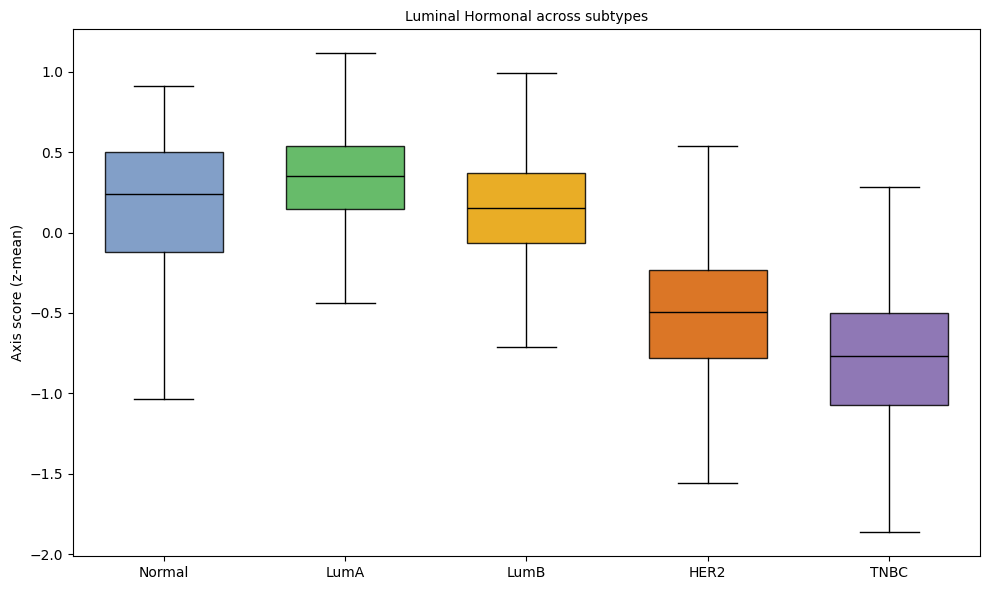

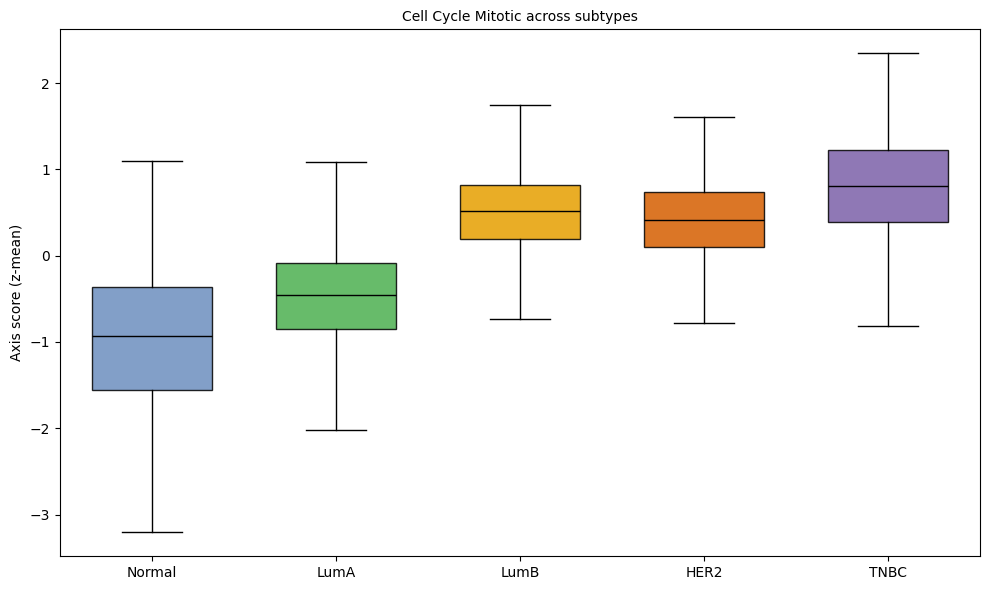

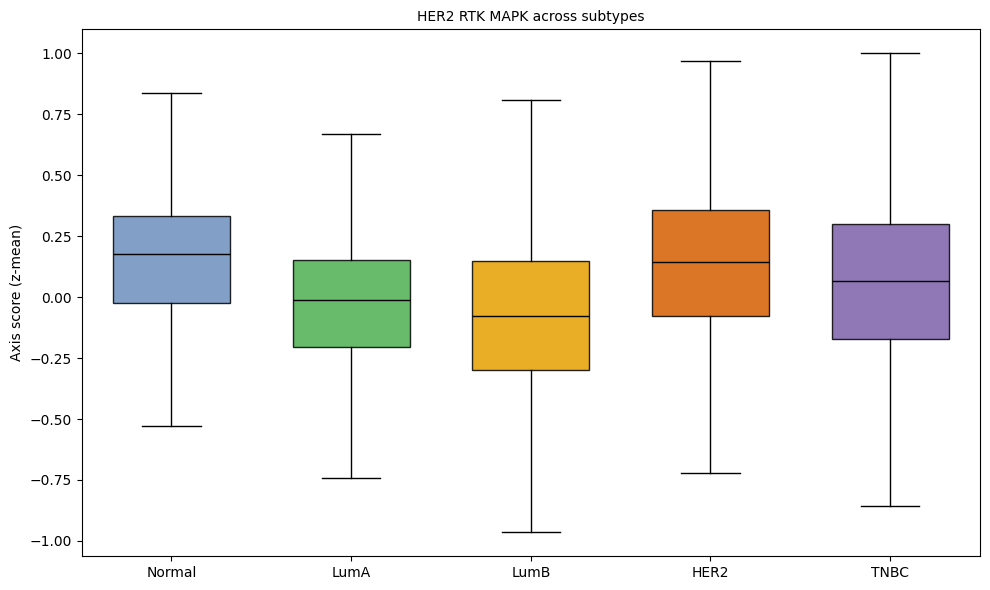

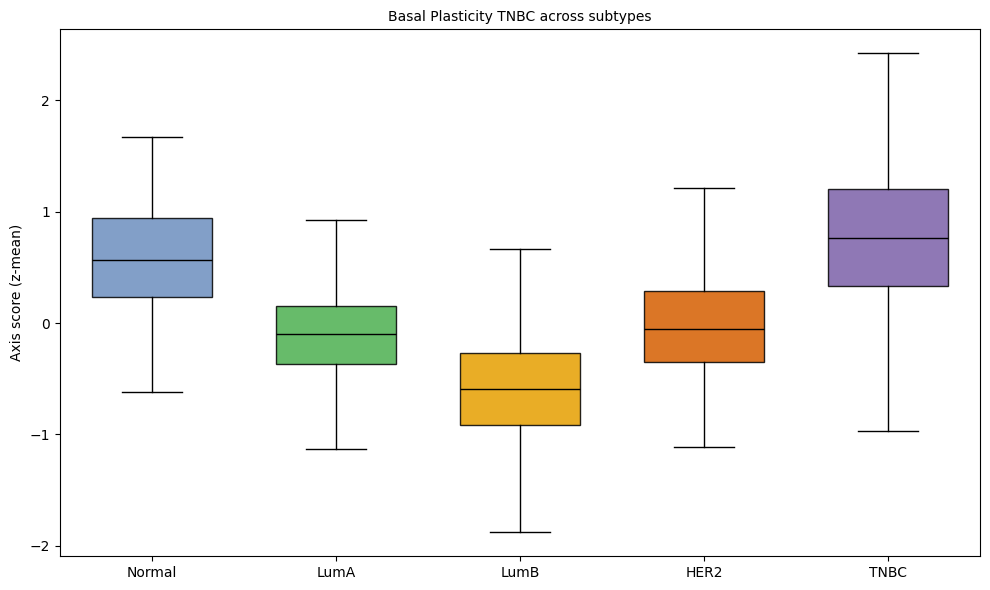

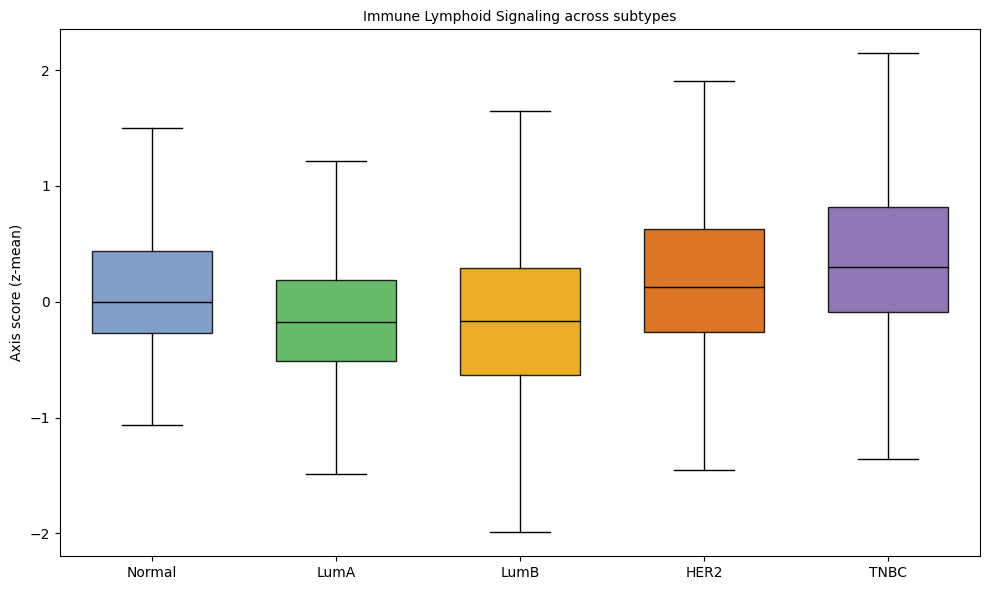

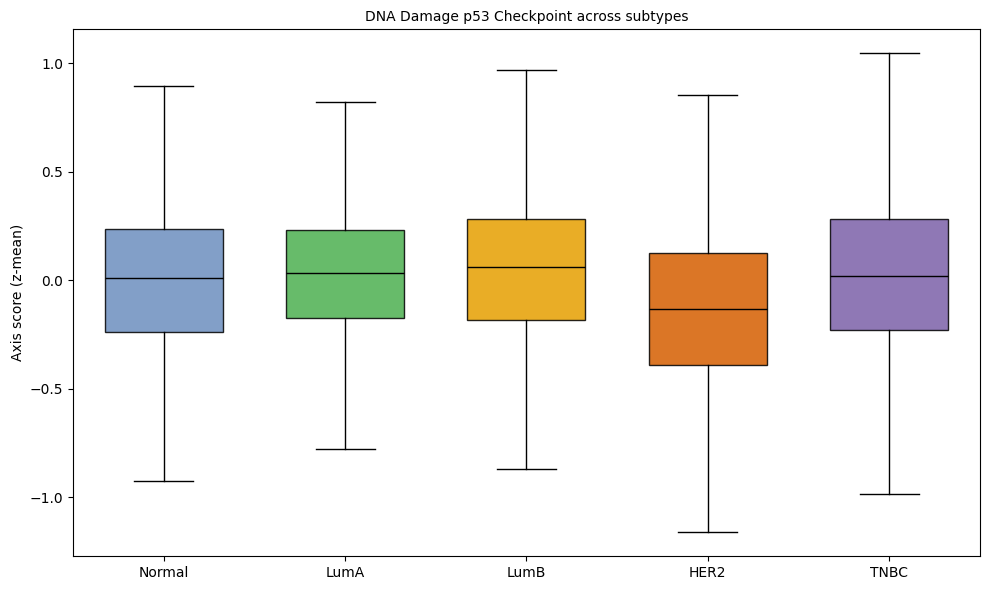

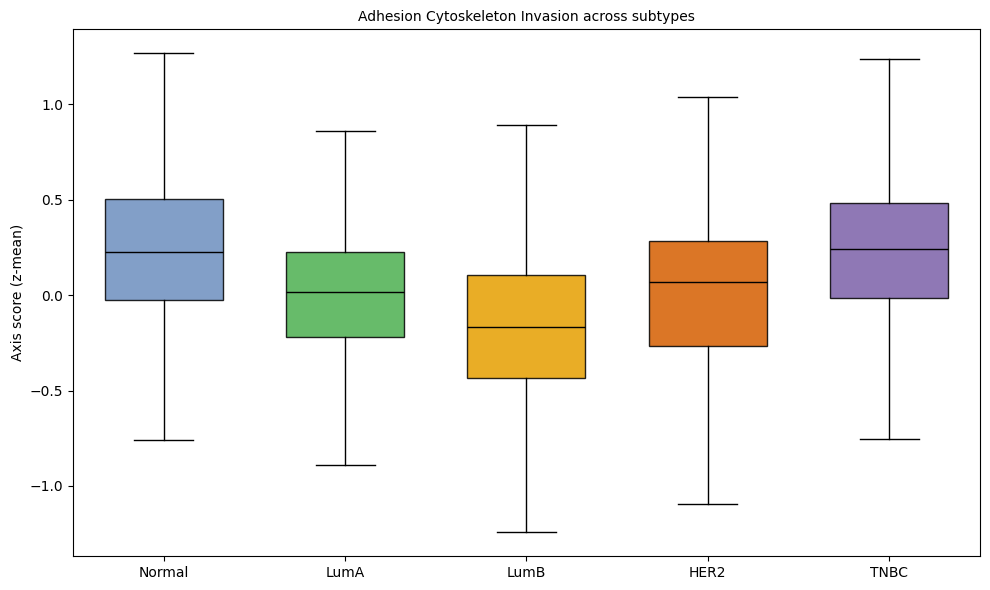

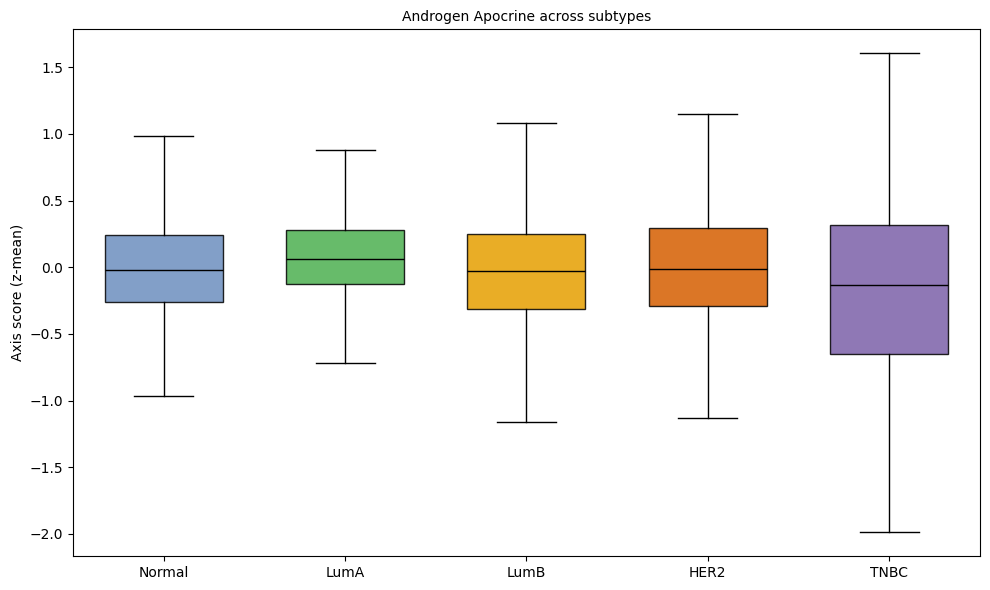

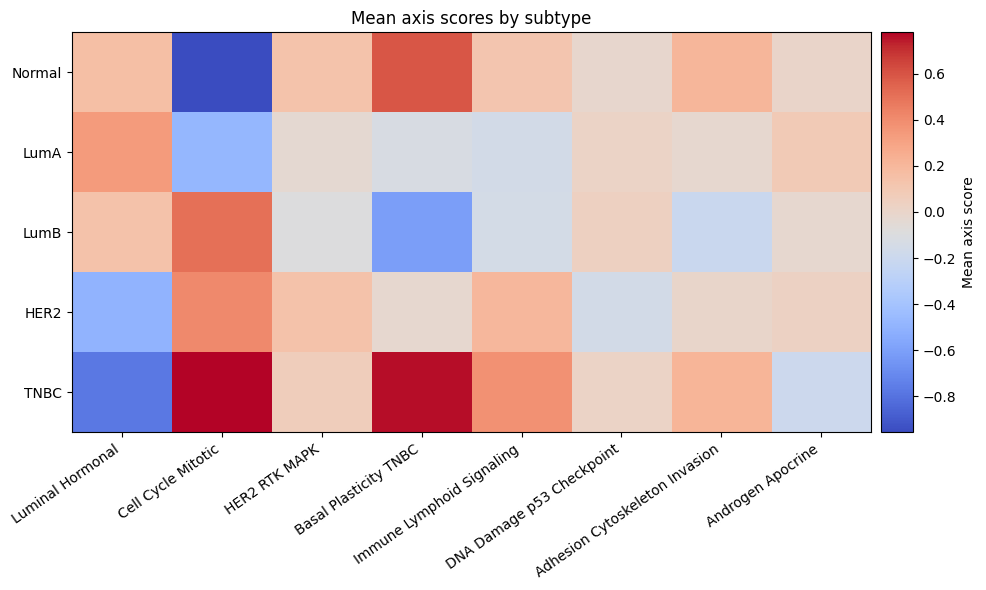

,Luminal Hormonal,Cell Cycle Mitotic,HER2 RTK MAPK,Basal Plasticity TNBC,Immune Lymphoid Signaling,DNA Damage p53 Checkpoint,Adhesion Cytoskeleton Invasion,Androgen Apocrine
label,,,,,,,,
Normal,0.159067,-0.956158,0.129159,0.592832,0.116887,-0.020067,0.205229,0.001819
LumA,0.338150,-0.481061,-0.039471,-0.126465,-0.153632,0.014999,-0.024860,0.083630
LumB,0.140645,0.508015,-0.091295,-0.604219,-0.146686,0.039922,-0.203841,-0.026521
HER2,-0.497649,0.409765,0.135789,-0.026923,0.200683,-0.155226,-0.006880,0.030145
TNBC,-0.773902,0.779296,0.065084,0.763127,0.377226,0.016710,0.210145,-0.192364


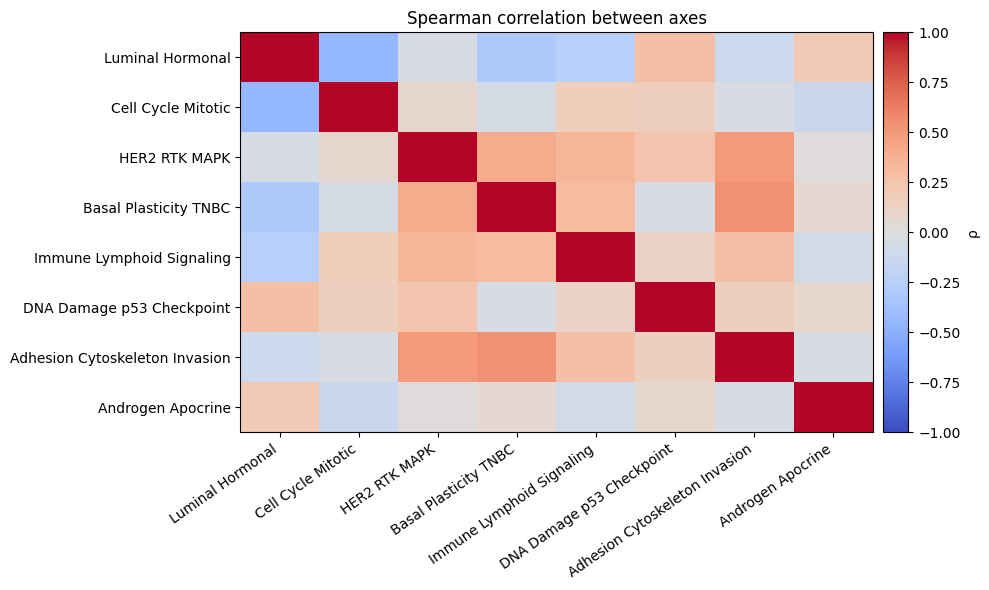

,Luminal Hormonal,Cell Cycle Mitotic,HER2 RTK MAPK,Basal Plasticity TNBC,Immune Lymphoid Signaling,DNA Damage p53 Checkpoint,Adhesion Cytoskeleton Invasion,Androgen Apocrine
Luminal Hormonal,1.000000,-0.450382,-0.053581,-0.304812,-0.253536,0.282852,-0.116573,0.210541
Cell Cycle Mitotic,-0.450382,1.000000,0.082964,-0.058034,0.167000,0.163544,-0.032269,-0.134339
HER2 RTK MAPK,-0.053581,0.082964,1.000000,0.400797,0.341884,0.238761,0.499970,0.008609
Basal Plasticity TNBC,-0.304812,-0.058034,0.400797,1.000000,0.297965,-0.033868,0.542252,0.068108
Immune Lymphoid Signaling,-0.253536,0.167000,0.341884,0.297965,1.000000,0.129036,0.286765,-0.082712
DNA Damage p53 Checkpoint,0.282852,0.163544,0.238761,-0.033868,0.129036,1.000000,0.154544,0.091087
Adhesion Cytoskeleton Invasion,-0.116573,-0.032269,0.499970,0.542252,0.286765,0.154544,1.000000,-0.049021
Androgen Apocrine,0.210541,-0.134339,0.008609,0.068108,-0.082712,0.091087,-0.049021,1.000000


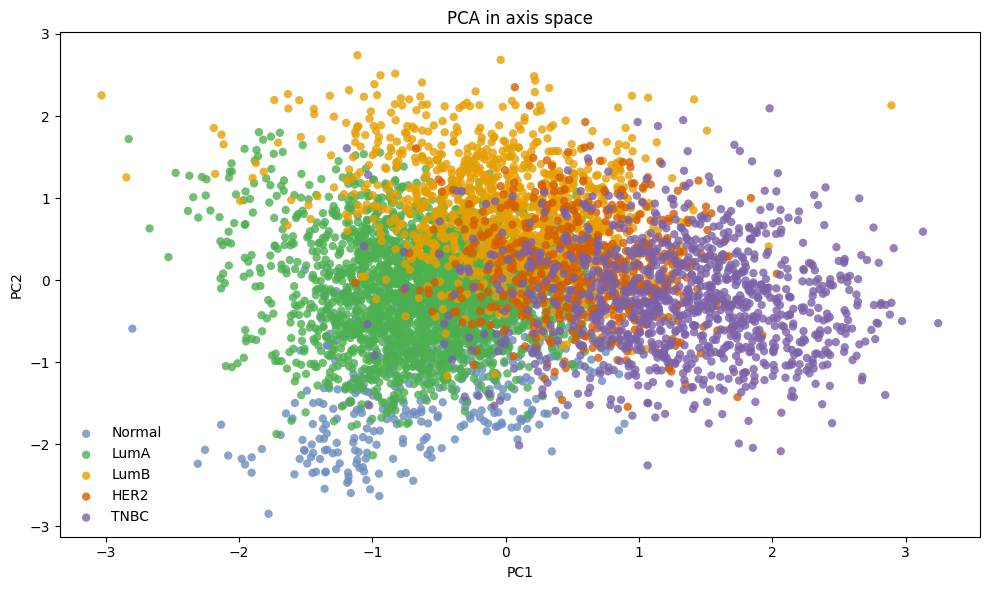

/home/alejandro/.pyenv/versions/3.14.3/envs/Torch/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/alejandro/.pyenv/versions/3.14.3/envs/Torch/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


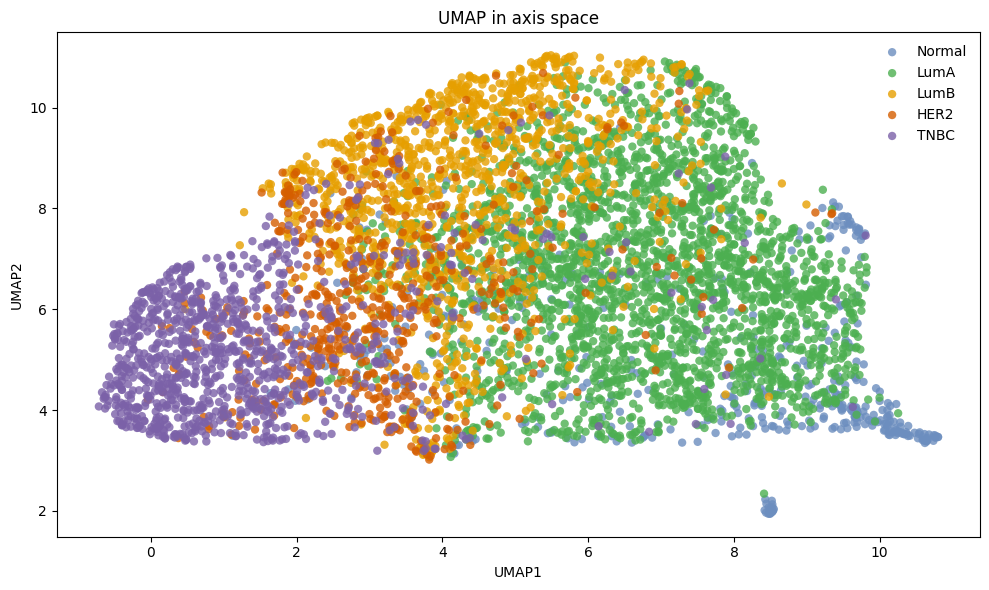

,Axis,Axis_pretty,Kruskal_H,p_value,p_fdr
0,Luminal Hormonal,Luminal Hormonal,3124.975065,0.000000e+00,0.000000e+00
1,Cell Cycle Mitotic,Cell Cycle Mitotic,3134.372728,0.000000e+00,0.000000e+00
2,Basal Plasticity TNBC,Basal Plasticity TNBC,2671.647035,0.000000e+00,0.000000e+00
3,Adhesion Cytoskeleton Invasion,Adhesion Cytoskeleton Invasion,633.678400,7.955936e-136,1.591187e-135
4,Immune Lymphoid Signaling,Immune Lymphoid Signaling,568.246302,1.153229e-121,1.845167e-121
5,HER2 RTK MAPK,HER2 RTK MAPK,337.672575,8.041972e-72,1.072263e-71
6,Androgen Apocrine,Androgen Apocrine,158.256933,3.457247e-33,3.951140e-33
7,DNA Damage p53 Checkpoint,DNA Damage p53 Checkpoint,115.615876,4.610707e-24,4.610707e-24


In [32]:
plot_axis_boxplots(meta_scores, label_col="label")
heat = plot_axis_heatmap_by_subtype(meta_scores, label_col="label")
display(heat)
corr = plot_axis_correlation(meta_scores)
display(corr)
plot_axis_embedding(meta_scores, label_col="label")
stats_df = axis_stats_by_subtype(meta_scores, label_col="label")
display(stats_df)


,Subtype,Axis,Axis_pretty,n_subtype,n_rest,mean_subtype,mean_rest,delta_mean,median_subtype,median_rest,delta_median,U,p_value,rank_biserial,AUC_effect,cohen_d,direction,p_fdr_global,p_fdr_subtype
0,HER2,Luminal Hormonal,Luminal Hormonal,602,5210,-0.497649,0.057502,-0.555151,-0.493629,0.186466,-0.680094,604849.0,7.361947e-135,-0.614306,0.192847,-1.051221,down_in_subtype,3.680973e-134,5.889557e-134
1,HER2,Cell Cycle Mitotic,Cell Cycle Mitotic,602,5210,0.409765,-0.047347,0.457112,0.415469,-0.044744,0.460214,2110354.0,5.606280e-44,0.345709,0.672854,0.556728,up_in_subtype,1.495008e-43,2.242512e-43
2,HER2,HER2 RTK MAPK,HER2 RTK MAPK,602,5210,0.135789,-0.015690,0.151479,0.143334,0.003523,0.139811,1980128.0,4.203448e-26,0.262668,0.631334,0.452017,up_in_subtype,9.890466e-26,1.120920e-25
3,HER2,DNA Damage p53 Checkpoint,DNA Damage p53 Checkpoint,602,5210,-0.155226,0.017936,-0.173161,-0.131874,0.033090,-0.164964,1163735.0,3.161131e-25,-0.257921,0.371039,-0.462696,down_in_subtype,6.655012e-25,6.322262e-25
4,HER2,Immune Lymphoid Signaling,Immune Lymphoid Signaling,602,5210,0.200683,-0.023188,0.223871,0.125470,-0.069204,0.194674,1866654.0,1.909327e-14,0.190309,0.595154,0.338191,up_in_subtype,2.937426e-14,3.054923e-14
5,HER2,Androgen Apocrine,Androgen Apocrine,602,5210,0.030145,-0.003483,0.033628,-0.015347,0.017596,-0.032943,1536289.0,4.128304e-01,-0.020355,0.489822,0.066213,up_in_subtype,4.463031e-01,5.504405e-01
6,HER2,Basal Plasticity TNBC,Basal Plasticity TNBC,602,5210,-0.026923,0.003111,-0.030034,-0.051258,-0.046069,-0.005190,1561907.0,8.715491e-01,-0.004019,0.497990,-0.044893,down_in_subtype,8.938965e-01,9.290737e-01
7,HER2,Adhesion Cytoskeleton Invasion,Adhesion Cytoskeleton Invasion,602,5210,-0.006880,0.000795,-0.007675,0.068628,0.037092,0.031536,1564740.0,9.290737e-01,-0.002213,0.498894,-0.017519,down_in_subtype,9.290737e-01,9.290737e-01
8,LumA,Cell Cycle Mitotic,Cell Cycle Mitotic,2514,3298,-0.481061,0.366703,-0.847764,-0.454098,0.480195,-0.934293,1423419.0,0.000000e+00,-0.656642,0.171679,-1.178936,down_in_subtype,0.000000e+00,0.000000e+00
9,LumA,Luminal Hormonal,Luminal Hormonal,2514,3298,0.338150,-0.257765,0.595915,0.353716,-0.206382,0.560098,6742980.0,0.000000e+00,0.626544,0.813272,1.269563,up_in_subtype,0.000000e+00,0.000000e+00


,Subtype,Top_up_axes,Top_down_axes
0,HER2,"Cell Cycle Mitotic (Δ mean=+0.457, rb=+0.346) ...","Luminal Hormonal (Δ mean=-0.555, rb=-0.614) | ..."
1,LumA,"Luminal Hormonal (Δ mean=+0.596, rb=+0.627) | ...","Cell Cycle Mitotic (Δ mean=-0.848, rb=-0.657) ..."
2,LumB,"Cell Cycle Mitotic (Δ mean=+0.640, rb=+0.484) ...","Basal Plasticity TNBC (Δ mean=-0.762, rb=-0.68..."
3,Normal,"Basal Plasticity TNBC (Δ mean=+0.645, rb=+0.60...","Cell Cycle Mitotic (Δ mean=-1.040, rb=-0.629) ..."
4,TNBC,"Cell Cycle Mitotic (Δ mean=+0.946, rb=+0.662) ...","Luminal Hormonal (Δ mean=-0.940, rb=-0.867) | ..."


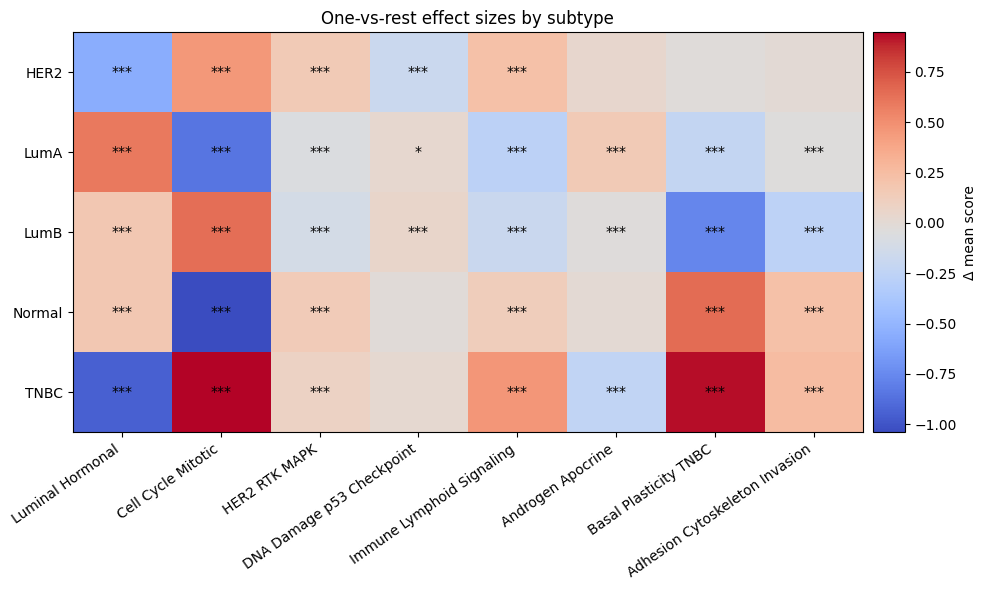

(Axis     Luminal Hormonal  Cell Cycle Mitotic  HER2 RTK MAPK  \
 Subtype                                                        
 HER2            -0.555151            0.457112       0.151479   
 LumA             0.595915           -0.847764      -0.069560   
 LumB             0.177316            0.640473      -0.115099   
 Normal           0.172998           -1.039894       0.140470   
 TNBC            -0.939807            0.946357       0.079037   
 
 Axis     DNA Damage p53 Checkpoint  Immune Lymphoid Signaling  \
 Subtype                                                         
 HER2                     -0.173161                   0.223871   
 LumA                      0.026432                  -0.270743   
 LumB                      0.050331                  -0.184932   
 Normal                   -0.021825                   0.127123   
 TNBC                      0.020292                   0.458094   
 
 Axis     Androgen Apocrine  Basal Plasticity TNBC  \
 Subtype                 

In [33]:
# ── One-vs-rest por subtipo ──
axes_order = list(AXES.keys())
ovr_df = one_vs_rest_axis_analysis(meta_scores, label_col="label", axes_order=axes_order)
display(ovr_df.head(20))

ovr_summary = summarize_one_vs_rest(ovr_df, top_n=3, sort_by="delta_mean")
display(ovr_summary)

plot_one_vs_rest_heatmap(ovr_df, value_col="delta_mean", fdr_col="p_fdr_subtype")


# Fin